In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split #treino e teste
from sklearn.metrics import accuracy_score, confusion_matrix #precisão e matrix e confusão

from sklearn.tree import DecisionTreeClassifier #Modelo de árvore de decisão
from sklearn.preprocessing import LabelEncoder #pré-processamento dos dados
import matplotlib.pyplot as plt #graficos
import seaborn as sns
#Exportações e visualizações da árvore
import graphlib
import graphviz
from sklearn.tree import export_graphviz



In [ ]:
credito = pd.read_csv('Credit.csv')
credito.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,'critical/other existing credit',radio/tv,1169,'no known savings',>=7,4,'male single',none,4,'real estate',67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,'existing paid',radio/tv,5951,<100,1<=X<4,2,'female div/dep/mar',none,2,'real estate',22,none,own,1,skilled,1,none,yes,bad
2,'no checking',12,'critical/other existing credit',education,2096,<100,4<=X<7,2,'male single',none,3,'real estate',49,none,own,1,'unskilled resident',2,none,yes,good
3,<0,42,'existing paid',furniture/equipment,7882,<100,4<=X<7,2,'male single',guarantor,4,'life insurance',45,none,'for free',1,skilled,2,none,yes,good
4,<0,24,'delayed previously','new car',4870,<100,1<=X<4,3,'male single',none,4,'no known property',53,none,'for free',2,skilled,2,none,yes,bad


In [ ]:
credito.shape

(1000, 21)

In [ ]:
#Separar os parâmetros e a classe
previsores = credito.iloc[:,0:20].values
classe = credito.iloc[:,20].values

In [ ]:
labelencoder1 = LabelEncoder()
previsores[:,0] = labelencoder1.fit_transform(previsores[:,0])

labelencoder2 = LabelEncoder()
previsores[:,2] = labelencoder2.fit_transform(previsores[:,2])

labelencoder3 = LabelEncoder()
previsores[:,3] = labelencoder3.fit_transform(previsores[:,3])

labelencoder5 = LabelEncoder()
previsores[:,5] = labelencoder5.fit_transform(previsores[:,5])

labelencoder6 = LabelEncoder()
previsores[:,6] = labelencoder6.fit_transform(previsores[:,6])

labelencoder8 = LabelEncoder()
previsores[:,8] = labelencoder8.fit_transform(previsores[:,8])

labelencoder9 = LabelEncoder()
previsores[:,9] = labelencoder9.fit_transform(previsores[:,9])

labelencoder11 = LabelEncoder()
previsores[:,11] = labelencoder11.fit_transform(previsores[:,11])

labelencoder13 = LabelEncoder()
previsores[:,13] = labelencoder13.fit_transform(previsores[:,13])

labelencoder14 = LabelEncoder()
previsores[:,14] = labelencoder14.fit_transform(previsores[:,14])

labelencoder16 = LabelEncoder()
previsores[:,16] = labelencoder16.fit_transform(previsores[:,16])

labelencoder18 = LabelEncoder()
previsores[:,18] = labelencoder18.fit_transform(previsores[:,18])

labelencoder19 = LabelEncoder()
previsores[:,19] = labelencoder19.fit_transform(previsores[:,19])

In [ ]:
#Separar os dados em treinamento e teste
X_treinamento, X_teste, y_treinamento, y_teste = train_test_split(previsores,
                                                                  classe,
                                                                  test_size = 0.3,
                                                                  random_state = 0)

In [ ]:
arvore = DecisionTreeClassifier() #Criar o modelo de árvore de decisão

In [ ]:
arvore.fit(X_treinamento, y_treinamento) #treina o modelo com os dados

DecisionTreeClassifier()

In [ ]:
previsoes = arvore.predict(X_teste) #faz o teste com os dados separados

In [ ]:
previsoes

array(['bad', 'good', 'good', 'good', 'good', 'bad', 'good', 'good',
       'good', 'bad', 'bad', 'bad', 'bad', 'good', 'bad', 'bad', 'good',
       'good', 'bad', 'bad', 'bad', 'bad', 'good', 'good', 'good', 'bad',
       'good', 'bad', 'bad', 'bad', 'good', 'bad', 'bad', 'bad', 'good',
       'bad', 'good', 'good', 'bad', 'good', 'good', 'bad', 'good', 'bad',
       'good', 'good', 'good', 'bad', 'bad', 'good', 'good', 'bad', 'bad',
       'good', 'good', 'bad', 'good', 'good', 'good', 'good', 'bad',
       'good', 'good', 'good', 'good', 'good', 'good', 'good', 'bad',
       'good', 'bad', 'good', 'bad', 'bad', 'good', 'good', 'bad', 'good',
       'good', 'good', 'good', 'good', 'good', 'good', 'good', 'good',
       'bad', 'bad', 'good', 'good', 'good', 'bad', 'bad', 'good', 'good',
       'good', 'good', 'good', 'good', 'bad', 'good', 'good', 'good',
       'good', 'good', 'good', 'bad', 'bad', 'good', 'good', 'good',
       'good', 'good', 'good', 'good', 'good', 'bad', 'good', 

In [ ]:
taxa_acerto = accuracy_score(y_teste, previsoes)
taxa_acerto

0.6966666666666667

In [ ]:
confusao = confusion_matrix(y_teste, previsoes)
confusao

array([[ 45,  41],
       [ 50, 164]])

In [ ]:
exportar = export_graphviz(
    arvore, out_file=None, filled=True,
    feature_names=credito.columns[0:20],
    class_names=['Mau pagador','Bom Pagador'],
    special_characters=True
)

graph = graphviz.Source(exportar)
graph.render("Arvore_de_decisao")
graph.view()

'Arvore_de_decisao.pdf'

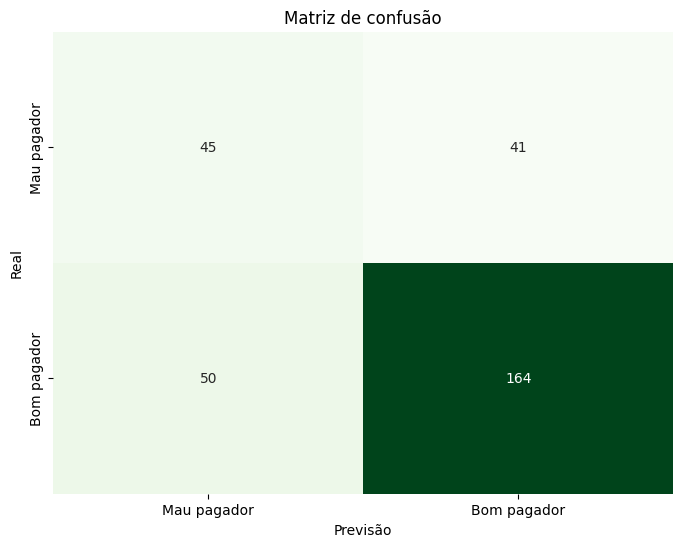

In [ ]:
# matrix = ConfunsionMatrix(GaussianNB())
# matrix.fit(X_treinamento, y_treinamento)
# previsoes = matrix.predict(X_teste, y_teste)
# matrix.poof()

plt.figure(figsize=(8,6))
sns.heatmap(confusao, annot=True, cmap="Greens", cbar=False, fmt="d",
xticklabels=['Mau pagador', 'Bom pagador'], yticklabels=['Mau pagador', 'Bom pagador'])
plt.title("Matriz de confusão")
plt.xlabel("Previsão")
plt.ylabel("Real")
plt.show()

Rede Bayesiana

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
naive_bayes = GaussianNB()

In [ ]:
naive_bayes.fit(X_treinamento, y_treinamento)
#treina os mesmos dados porém com algoritmo de rede bayesiana

GaussianNB()

In [ ]:
previsoes2 = naive_bayes.predict(X_teste)

In [ ]:
previsoes2

array(['bad', 'good', 'good', 'good', 'bad', 'good', 'good', 'good',
       'good', 'bad', 'bad', 'bad', 'good', 'bad', 'good', 'good', 'good',
       'good', 'bad', 'good', 'bad', 'good', 'bad', 'good', 'good', 'bad',
       'good', 'good', 'good', 'bad', 'good', 'good', 'good', 'good',
       'good', 'bad', 'good', 'good', 'good', 'good', 'good', 'bad',
       'good', 'good', 'good', 'bad', 'bad', 'bad', 'bad', 'bad', 'good',
       'bad', 'good', 'good', 'good', 'good', 'bad', 'good', 'good',
       'good', 'bad', 'good', 'good', 'good', 'good', 'good', 'good',
       'good', 'bad', 'good', 'good', 'good', 'good', 'good', 'bad',
       'good', 'good', 'good', 'good', 'good', 'good', 'good', 'good',
       'bad', 'good', 'good', 'bad', 'bad', 'good', 'bad', 'good', 'good',
       'good', 'good', 'good', 'good', 'good', 'good', 'good', 'good',
       'good', 'good', 'good', 'bad', 'good', 'good', 'bad', 'bad',
       'good', 'good', 'good', 'bad', 'good', 'good', 'bad', 'good',
      

In [ ]:
taxa_acerto = accuracy_score(y_teste, previsoes2)
taxa_acerto

0.71

In [ ]:
confusao = confusion_matrix(y_teste, previsoes2)
confusao

array([[ 41,  45],
       [ 42, 172]])